# Gated DeltaNet：从 DeltaNet 到 GDN / GDN-2 的门控 delta rule

线性注意力的核心是一个 **状态矩阵** $S\in\mathbb R^{K\times V}$，它把整段历史压进固定大小的内存，每来一个
token 就更新一次，读出 $o_t = S_t^\top q_t$。这一章我们沿着"状态怎么更新"这条主线，把 **两代 Gated
DeltaNet** 的数学一步步推到底：

| | 衰减门控 | delta rule（擦/写） | 出处 |
|---|---|---|---|
| **GDN v1** | per-**head** 标量 $g_t\in\mathbb R$ | 单标量 $\beta_t$ 同时管擦与写 | Qwen3-Next |
| **GDN-2** | per-**channel** $g_t\in\mathbb R^K$ | **erase $b_t$ / write $w_t$ 双门解耦** | Qwen3.5 |

路线图（每一节都会用数值**精确验证**，不是"差不多"）：

1. §2 先把 **delta rule 的几何**讲透——为什么 $(I-\beta_t k_tk_t^\top)$ 是"沿 $k_t$ 方向擦除"；
2. §3–§4 在它上面加 **门控**（GDN v1）、再把擦/写 **解耦成两个门**（GDN-2）；
3. §5 推导 **WY 表示**——把块内串行的擦除解成一次三角求逆，这是 chunk 并行 kernel 的数学地基；
4. §6 **逐段精读**真正的 chunk 实现（可读的参考实现，每段标注对应的 Triton kernel）；
5. §7 验证本仓库**完整解耦自 fla** 的 Triton kernel 与原版数值一致。

In [1]:
import sys, math
from pathlib import Path

import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
%matplotlib inline

ROOT = Path.cwd()
while not (ROOT / "common").exists() and ROOT != ROOT.parent:
    ROOT = ROOT.parent
CH = ROOT / "13-gated-deltanet"
sys.path.insert(0, str(ROOT)); sys.path.insert(0, str(CH))
sys.path.insert(0, str(ROOT / "11-deltanet")); sys.path.insert(0, str(ROOT / "12-kda"))

from common.nbtools import setup_cjk, show_code
setup_cjk()                                       # 中文字体 + retina 高清出图
from gdn import gated_delta_recurrent             # GDN v1：per-head 标量门控
from gdn2 import gdn2_recurrent                    # GDN-2：erase/write 双门控
from gdn2_naive import naive_recurrent_gdn2, naive_chunk_gdn2   # fla 参考（ground truth）
from deltanet import delta_rule_recurrent          # 退化对比
from kda import kda_recurrent                       # 退化对比

torch.manual_seed(0)
print("跑在", torch.cuda.get_device_name(0))

跑在 NVIDIA GeForce RTX 4090


## 1. 一条线看懂四代：状态更新规则

线性注意力的全部差异，只在"状态 $S$ 每步怎么更新"这一行。把四代叠在一起看（$\odot$ 为逐元素积）：

$$
\begin{aligned}
\textbf{DeltaNet}\;&: & S_t&=(I-\beta_t\,k_tk_t^\top)\,S_{t-1}+\beta_t\,k_t v_t^\top &&\text{(纠错，无遗忘)}\\
\textbf{KDA}\;&: & S_t&=(I-\beta_t\,k_tk_t^\top)\,\operatorname{diag}(e^{g_t})\,S_{t-1}+\beta_t\,k_t v_t^\top &&\text{(per-ch 遗忘+纠错)}\\
\textbf{GDN v1}\;&: & S_t&=(I-\beta_t\,k_tk_t^\top)\,e^{g_t}\,S_{t-1}+\beta_t\,k_t v_t^\top &&\text{($g_t$ 退化为标量)}\\
\textbf{GDN-2}\;&: & S_t&=\bigl(I-k_t(b_t\odot k_t)^\top\bigr)\operatorname{diag}(e^{g_t})\,S_{t-1}+k_t(w_t\odot v_t)^\top &&\text{(erase/write 解耦)}
\end{aligned}
$$

退化链（令某些门退化，即得上一代）：

$$\textbf{GDN-2}\xrightarrow{\,b_t=w_t=\beta_t\,}\textbf{KDA}\xrightarrow{\,g_t\to\text{标量}\,}\textbf{GDN v1}\xrightarrow{\,g_t\equiv0\,}\textbf{DeltaNet}.$$

先把这条链用数值钉死，再逐节展开数学。

In [2]:
B, H, T, D = 2, 2, 128, 64
q = torch.randn(B, H, T, D, device="cuda")
k = torch.randn(B, H, T, D, device="cuda")
v = torch.randn(B, H, T, D, device="cuda")
beta = torch.rand(B, H, T, device="cuda")

# ① GDN(g=0) == DeltaNet：门控关掉（e^0=1，不遗忘），只剩 delta 纠错
g0 = torch.zeros(B, H, T, device="cuda")
d01 = (gated_delta_recurrent(q, k, v, g0, beta, l2norm=True)
       - delta_rule_recurrent(q, k, v, beta, l2norm=True)).abs().max().item()
# ② GDN(标量 g) == KDA(把同一个 g 广播到所有通道)：per-head 是 per-channel 的特例
g_scalar = F.logsigmoid(torch.randn(B, H, T, device="cuda"))
d02 = (gated_delta_recurrent(q, k, v, g_scalar, beta, l2norm=True)
       - kda_recurrent(q, k, v, g_scalar[..., None].expand(B, H, T, D), beta, l2norm=True)).abs().max().item()
print(f"① GDN(g=0)   vs DeltaNet      max diff: {d01:.2e}")
print(f"② GDN(标量g) vs KDA(广播g)     max diff: {d02:.2e}")
print("→ 退化链成立：GDN 是 KDA 的 per-head 标量门控特例，g=0 时进一步退化为 DeltaNet。")

① GDN(g=0)   vs DeltaNet      max diff: 0.00e+00
② GDN(标量g) vs KDA(广播g)     max diff: 0.00e+00
→ 退化链成立：GDN 是 KDA 的 per-head 标量门控特例，g=0 时进一步退化为 DeltaNet。


## 2. 先把 delta rule 的几何讲透

GDN 系列的核心是 **delta rule**。要理解后面的双门控与 WY 表示，得先看清它在做什么。

### 2.1 朴素线性注意力的毛病：只加不改

最朴素的线性注意力是 $S_t=S_{t-1}+k_tv_t^\top$，读出

$$o_t=S_t^\top q_t=\sum_{i\le t}(q_t^\top k_i)\,v_i.$$

如果各个 $k_i$ **彼此不正交**，那么用 $k_t$ 去读时会混进别的 $v_i$（键冲突 / 串扰）。而且写入永远是"叠加"，
旧的错误信息无法被覆盖。

### 2.2 delta rule：先擦后写

delta rule 借了在线学习里 *delta 规则* 的思想：把状态 $S$ 看成一个线性映射 $k\mapsto v$，每来一对 $(k_t,v_t)$
就像做一步梯度修正。具体分三步——

$$
\underbrace{\hat v_t=S_{t-1}^\top k_t}_{\text{① 读出 }k_t\text{ 方向的旧值}}\qquad
\underbrace{\Delta_t=\beta_t\,(v_t-\hat v_t)}_{\text{② 算误差}}\qquad
\underbrace{S_t=S_{t-1}+k_t\,\Delta_t^\top}_{\text{③ 沿 }k_t\text{ 写回修正}}
$$

把它们合并，关键的代数变形是把 $\hat v_t=S_{t-1}^\top k_t$ 代回去：

$$
S_t=S_{t-1}+\beta_t\,k_t\bigl(v_t-S_{t-1}^\top k_t\bigr)^\top
   =S_{t-1}+\beta_t\,k_tv_t^\top-\beta_t\,k_tk_t^\top S_{t-1}
   =\boxed{(I-\beta_t\,k_tk_t^\top)\,S_{t-1}+\beta_t\,k_tv_t^\top}.
$$

### 2.3 $(I-\beta_t k_tk_t^\top)$ 是"沿 $k_t$ 方向的擦除"

当 $\lVert k_t\rVert=1$、$\beta_t=1$ 时，$I-k_tk_t^\top$ 正是把向量在 $k_t$ 方向的分量**完全清零**的正交投影
（保留垂直于 $k_t$ 的部分）。所以 delta rule 等价于：**写入 $k_t$ 之前，先把状态里 $k_t$ 方向已经存的旧内容
擦掉**，再写新的 $v_t$。$\beta_t\in[0,1]$ 则是"擦多少"的力度。这从根上治了 §2.1 的键冲突。下面用一个 2D 例子
把"擦除"画出来。

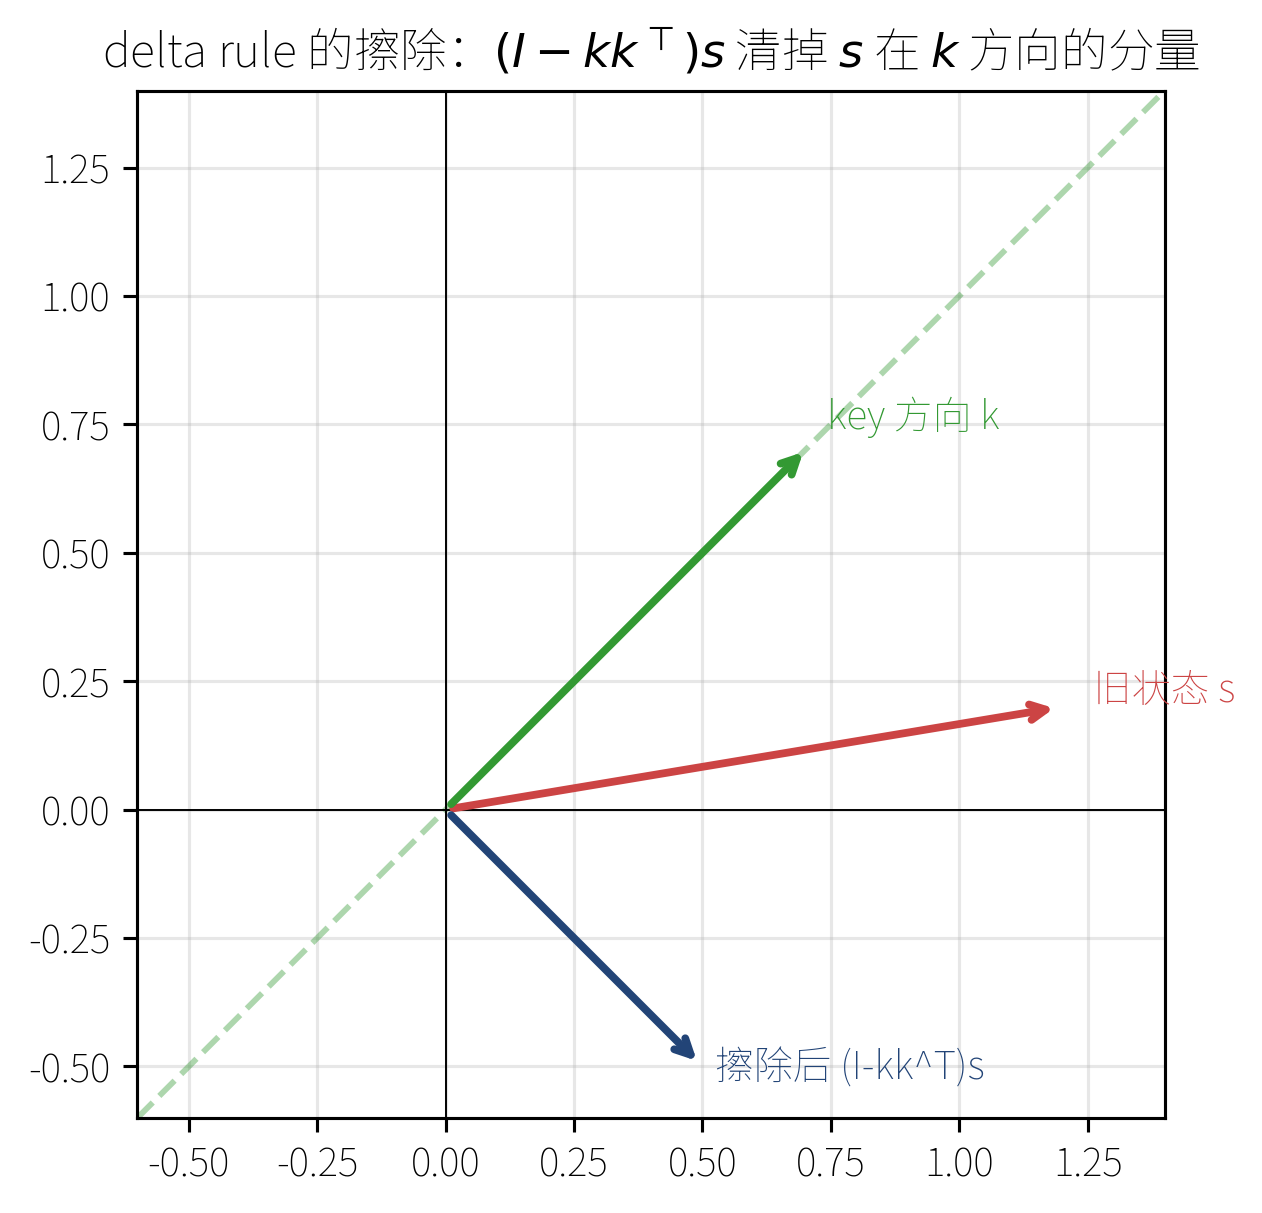

擦除后向量与 k 正交（在 k 方向的分量为 0）：s_erased · k = 2.9802322387695312e-08
→ 写入新 v 前先沿 k 擦掉旧值，这就是 delta rule 治键冲突的几何本质。


In [3]:
# 2D 演示：状态在 k 方向有一个旧分量，(I - k k^T) 把它沿 k 擦掉，只留垂直分量
k_dir = torch.tensor([1.0, 1.0]); k_dir = k_dir / k_dir.norm()      # 单位 key 方向
s_old = torch.tensor([1.2, 0.2])                                    # 某个旧状态向量
P = torch.eye(2) - torch.outer(k_dir, k_dir)                        # 擦除算子 I - k k^T
s_erased = P @ s_old

plt.figure(figsize=(4.6, 4.6))
ax = plt.gca()
for vec, c, lab in [(s_old, "#C44", "旧状态 s"), (s_erased, "#247", "擦除后 (I-kk^T)s"), (k_dir, "#393", "key 方向 k")]:
    ax.annotate("", xy=vec.tolist(), xytext=(0, 0), arrowprops=dict(arrowstyle="->", color=c, lw=2))
    ax.text(vec[0] * 1.05, vec[1] * 1.05, lab, color=c)
ax.axline((0, 0), slope=(k_dir[1] / k_dir[0]).item(), color="#393", ls="--", alpha=0.4)
ax.set_xlim(-0.6, 1.4); ax.set_ylim(-0.6, 1.4); ax.set_aspect("equal"); ax.grid(alpha=0.3)
ax.axhline(0, color="k", lw=0.5); ax.axvline(0, color="k", lw=0.5)
ax.set_title("delta rule 的擦除：$(I-kk^\\top)s$ 清掉 $s$ 在 $k$ 方向的分量")
plt.tight_layout(); plt.show()
print("擦除后向量与 k 正交（在 k 方向的分量为 0）：s_erased · k =", (s_erased @ k_dir).item())
print("→ 写入新 v 前先沿 k 擦掉旧值，这就是 delta rule 治键冲突的几何本质。")

## 3. 加上遗忘：门控衰减（GDN v1）

delta rule 解决了"定向覆盖"，但它**不会主动遗忘**——很久以前写入、之后再没被覆盖的内容会一直留在 $S$ 里。
于是在擦除算子之外，再给状态乘一个**衰减门** $\operatorname{diag}(e^{g_t})$（$g_t\le 0$，故 $e^{g_t}\in(0,1]$）：

$$S_t=(I-\beta_t k_tk_t^\top)\,\operatorname{diag}(e^{g_t})\,S_{t-1}+\beta_t k_tv_t^\top.$$

门控的**粒度**区分了两代：

- **KDA（第 12 章）**：$g_t\in\mathbb R^K$ 是 per-channel 向量——每个 key 通道独立遗忘，最灵活；
- **GDN v1（本章）**：$g_t\in\mathbb R$ 是 per-head 标量——整个状态矩阵统一遗忘，每个 head 只存 1 个数，
  更省更快。这是 Qwen3-Next 的工程取舍（配 Causal Conv1D + L2norm(Q/K)，每 4 层插 1 层 full attention）。

所以 **GDN v1 就是 KDA 把门控从"逐通道"退化成"逐头标量"**。`gdn.py:gated_delta_recurrent` 逐步实现，注意它的
$g$ 形状是 `[B,H,T]`，比 KDA 少一维 $K$。上一格 §1 的 ② 已数值验证了"GDN(标量 $g$) ≡ KDA(把 $g$ 广播到各通道)"。

## 4. GDN-2：把 erase 与 write 解耦成两个门

### 4.1 动机：一个 $\beta_t$ 同时管两件事，太挤了

回看 delta rule 的合并式，**同一个标量 $\beta_t$** 既出现在擦除算子 $(I-\beta_t k_tk_t^\top)$ 里，又出现在写入项
$\beta_t k_tv_t^\top$ 里。也就是说"擦掉多少旧值"和"写入多少新值"被绑成了一个数。但这两件事本该独立——也许我想
**大幅擦除**某个方向的陈旧记忆，却只**轻微写入**新内容，单个 $\beta_t$ 做不到。

### 4.2 解耦：erase 门 $b$ 与 write 门 $w$

GDN-2 把这一个标量拆成两个 per-channel 向量门，并保留 per-channel 衰减 $g$：

$$\boxed{\;S_t=\underbrace{\bigl(I-k_t\,(b_t\odot k_t)^\top\bigr)}_{\text{erase 门 }b_t\in\mathbb R^K}
        \operatorname{diag}(e^{g_t})\,S_{t-1}
      +\underbrace{k_t\,(w_t\odot v_t)^\top}_{\text{write 门 }w_t\in\mathbb R^V}\;}$$

逐项拆开看它在做什么：

- $\operatorname{diag}(e^{g_t})\,S_{t-1}$：**衰减**，per-channel 遗忘（与 KDA 同）。记 $\hat S=\operatorname{diag}(e^{g_t})S_{t-1}$。
- $\bigl(I-k_t(b_t\odot k_t)^\top\bigr)\hat S$：**擦除**。其中 $(b_t\odot k_t)^\top\hat S$ 读出"按 $b_t$ 逐通道加权的
  $k_t$ 方向旧值"，再被 $k_t(\cdot)^\top$ 沿 $k_t$ 减掉。$b_t$ 的每个分量独立决定对应 key 通道**擦多少**。
- $k_t(w_t\odot v_t)^\top$：**写入**按 $w_t$ 逐通道缩放后的新值，$w_t$ 独立决定**写多少**。

把它写成"先衰减、再擦、再写、最后读"的逐 token 四步（这正是 `gdn2.py:gdn2_recurrent` 的循环体）：

$$
\hat S=\operatorname{diag}(e^{g_t})S_{t-1},\quad
\text{erase}=(b_t\odot k_t)^\top\hat S,\quad
v^{\text{new}}_t=w_t\odot v_t-\text{erase},\quad
S_t=\hat S+k_t\,(v^{\text{new}}_t)^\top,\quad
o_t=S_t^\top q_t.
$$

退化检查：令 $b_t=w_t=\beta_t$（标量广播），$\bigl(I-k_t(\beta_t k_t)^\top\bigr)$ 与 $k_t(\beta_t v_t)^\top$ 就回到了
KDA 的擦除算子与写入项。下面数值验证。

In [4]:
B, H, T, K, V = 2, 2, 96, 64, 64
q = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1)   # 预 L2norm，统一 l2norm=False
k = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1)
v = torch.randn(B, H, T, V, device="cuda")
g = F.logsigmoid(torch.randn(B, H, T, K, device="cuda"))           # per-channel decay
beta = torch.rand(B, H, T, device="cuda")

# ③ b = w = beta（广播到通道）→ GDN-2 退化为 KDA
b = beta[..., None].expand(B, H, T, K)
w = beta[..., None].expand(B, H, T, V)
o_gdn2 = gdn2_recurrent(q, k, v, g, b, w, l2norm=False)
d3 = (o_gdn2 - kda_recurrent(q, k, v, g, beta, l2norm=False)).abs().max().item()
# ④ 自写简要版 vs fla 官方参考实现（gdn2_naive），应数值一致
o_ref, _ = naive_recurrent_gdn2(*(x.transpose(1, 2) for x in (q, k, v, g)), b.transpose(1, 2), w.transpose(1, 2))
d4 = (o_gdn2 - o_ref.transpose(1, 2)).abs().max().item()
print(f"③ GDN-2(b=w=β) vs KDA                 max diff: {d3:.2e}")
print(f"④ 自写 gdn2_recurrent vs fla naive     max diff: {d4:.2e}")
print("→ 双门控在 b=w=β 时精确退化为 KDA；自写简要版与 fla 官方参考逐位对齐。")

③ GDN-2(b=w=β) vs KDA                 max diff: 1.49e-08
④ 自写 gdn2_recurrent vs fla naive     max diff: 0.00e+00
→ 双门控在 b=w=β 时精确退化为 KDA；自写简要版与 fla 官方参考逐位对齐。


### 4.3 直观：erase 门能独立控制"擦多快"

下面把 erase 门的作用画出来：在 $t=0$ 写入一条信息 $(k_0\to v_0)$，之后每步都用同一个 $k_0$ 反复查询，看读出
强度随时间的变化。**固定 write 门、只调 erase 门 $b$**：$b$ 越大，后续 token 越倾向于沿 $k_0$ 把这条旧记忆擦掉。
这正是单个 $\beta$ 无法独立实现的——它会同时改变写入强度。

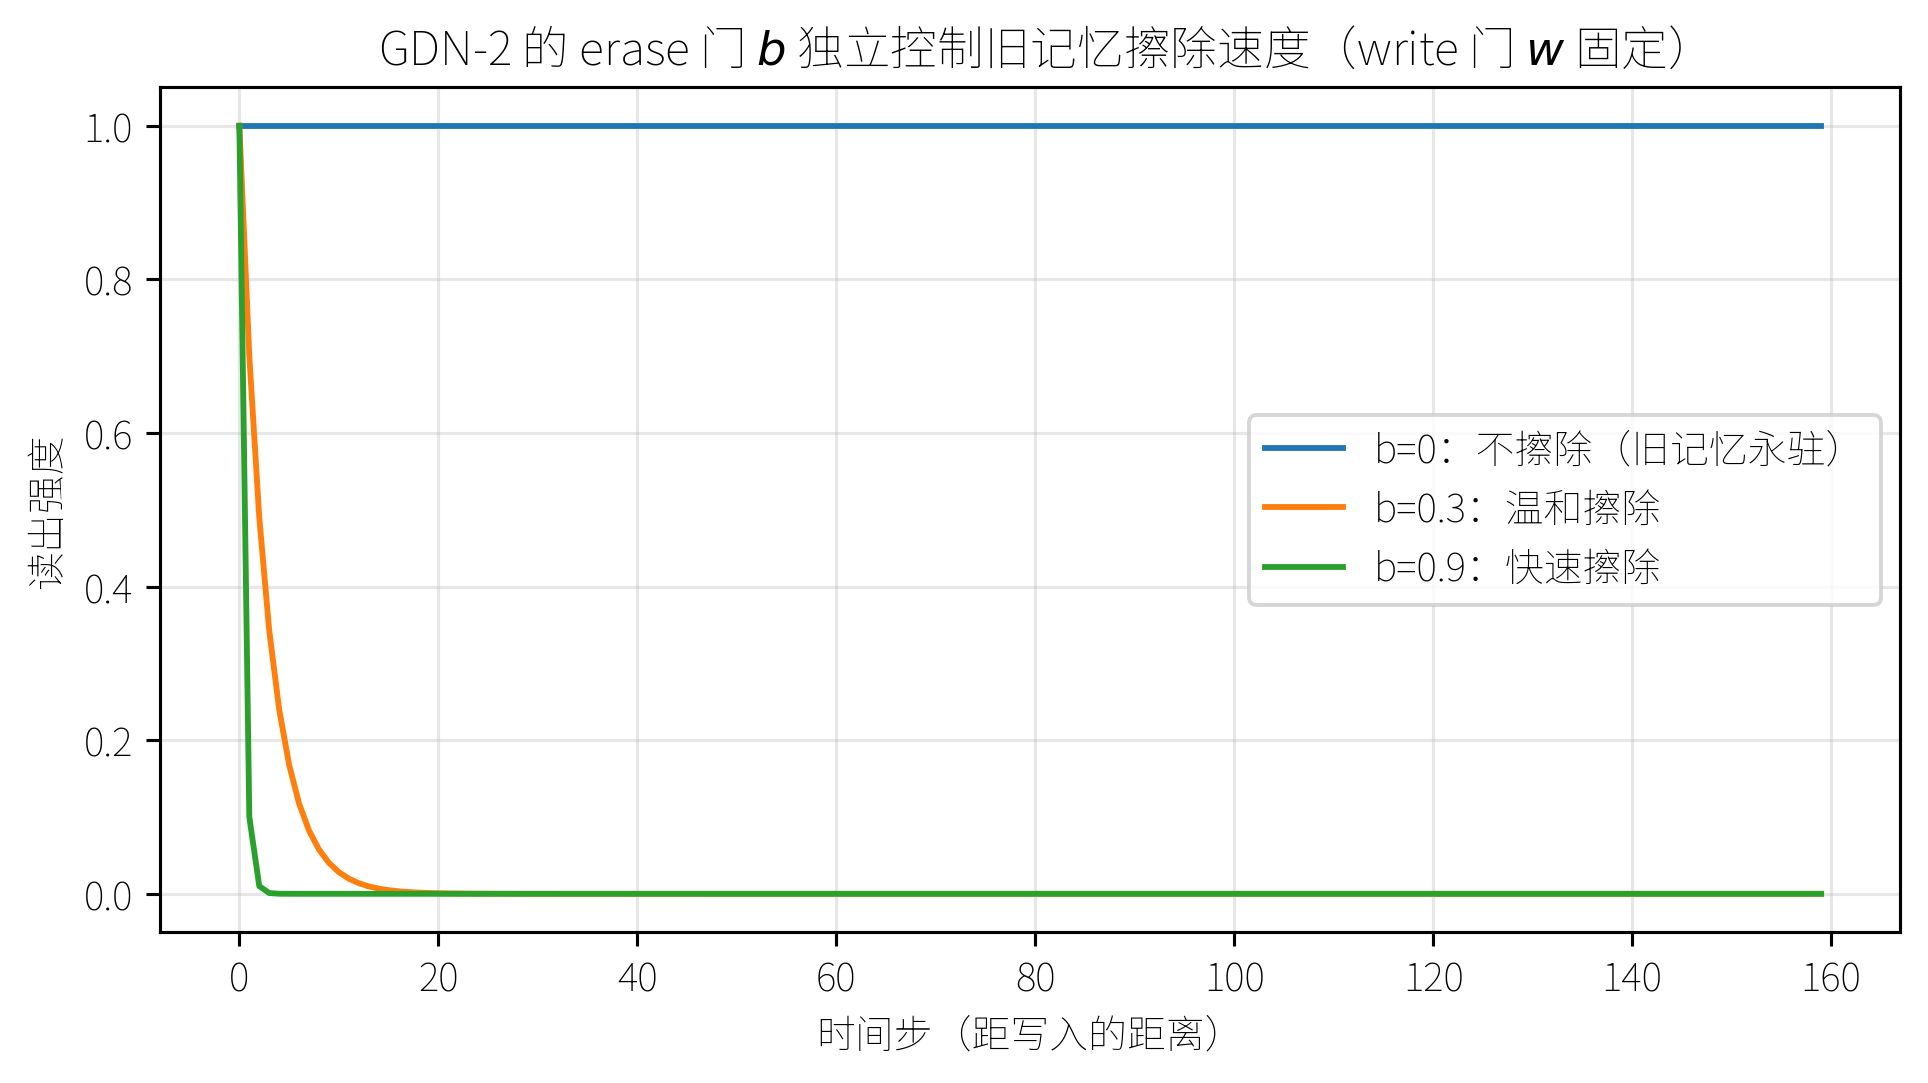

erase 门越大，后续 token 沿同方向对旧值的擦除越强——与写入强度 w 解耦。


In [5]:
T = 160
def trace(b_val, w_val=1.0):
    K = V = 16
    q = torch.zeros(1, 1, T, K, device="cuda"); k = torch.zeros(1, 1, T, K, device="cuda")
    v = torch.zeros(1, 1, T, V, device="cuda"); g = torch.zeros(1, 1, T, K, device="cuda")  # 不衰减，单看门控
    b = torch.full((1, 1, T, K), b_val, device="cuda"); w = torch.full((1, 1, T, V), w_val, device="cuda")
    k[0, 0, :, 0] = 1.0; q[0, 0, :, 0] = 1.0                         # 每步 key=query=e0（同方向）
    v[0, 0, 0, 0] = 1.0                                              # t=0 写入 e0->e0
    return gdn2_recurrent(q, k, v, g, b, w, l2norm=False, scale=1.0)[0, 0, :, 0].detach().cpu().numpy()

plt.figure(figsize=(7, 4))
for bv, name in [(0.0, "b=0：不擦除（旧记忆永驻）"), (0.3, "b=0.3：温和擦除"), (0.9, "b=0.9：快速擦除")]:
    plt.plot(trace(bv), label=name)
plt.xlabel("时间步（距写入的距离）"); plt.ylabel("读出强度")
plt.title("GDN-2 的 erase 门 $b$ 独立控制旧记忆擦除速度（write 门 $w$ 固定）")
plt.legend(); plt.grid(alpha=0.3); plt.tight_layout(); plt.show()
print("erase 门越大，后续 token 沿同方向对旧值的擦除越强——与写入强度 w 解耦。")

## 5. chunk 并行的数学核心：WY 表示（逐步推导）

前面的 recurrent 形式是 $O(T)$ **串行**的，GPU 上慢。生产 kernel 用 **chunk-parallel**：把序列切成大小 $C$（fla
里 $C=64$）的块，**块内**用矩阵运算一次算完、**块间**用一个状态递推。难点在块内——擦除算子是逐 token **串行相乘**
的，不能直接并行。这一节把"串行擦除"一步步化成"一次三角求逆"。

### 5.1 块内展开：看见串行的下三角依赖

只看一个块，块起点状态记为 $S$。对块内位置 $i=0,1,\dots,C-1$，把"先衰减、再擦、再写"代进去。为聚焦结构，先把
逐通道衰减 $e^{g}$ 折进记号（写成 $\tilde k_i=k_i\odot e^{g^{\mathrm{cum}}_i}$ 等，细节下面补），块内第 $i$ 步的
**有效写入** $u_i$ 满足

$$u_i=\underbrace{w_i\odot v_i}_{\text{本步想写的}}-\sum_{j<i}\underbrace{\bigl[(b_i\odot k_i)^\top \tilde k_j\bigr]}_{=\,T_{ij}}\,u_j.$$

直觉：位置 $i$ 在写入前要擦掉 $k_i$ 方向的旧值，而这"旧值"里就包含了**同一块内前面 $j<i$ 步刚写进去的 $u_j$**。
于是 $u_i$ 依赖所有 $u_j\ (j<i)$ —— 一个**严格下三角**的串行依赖。

### 5.2 写成线性方程组，一次解开

把块内所有 $u_i$ 摞成矩阵 $U=[u_0;\dots;u_{C-1}]$、$WV=[w_0\odot v_0;\dots]$，上式就是

$$U=WV-T\,U\;\Longrightarrow\;(I+T)\,U=WV\;\Longrightarrow\;\boxed{U=(I+T)^{-1}\,WV}.$$

这就是 **WY / UT transform**：一个严格下三角矩阵 $T$ 编码了块内所有"擦除-写入"的相互作用，求一次逆 $(I+T)^{-1}$
就把 $C$ 步串行依赖**一次性解开**，块内于是可以并行。其中

$$T_{ij}=\sum_d (b_i\odot k_i)_d\,k_{j,d}\,e^{\,g^{\mathrm{cum}}_{i,d}-g^{\mathrm{cum}}_{j,d}}\quad(i>j),\qquad T\ \text{严格下三角},$$

即"位置 $i$ 的 erase-read $(b_i\odot k_i)$ 撞上位置 $j$ 的 write 方向 $k_j$"的强度，带 $i,j$ 间的逐通道衰减
$e^{g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}$（$g^{\mathrm{cum}}$ 是块内 $g$ 的前缀和）。

### 5.3 $(I+T)^{-1}$ 怎么算——前向替换

$T$ 严格下三角 $\Rightarrow I+T$ 是**单位下三角**，其逆也是单位下三角，可用**前向替换**逐行 $O(C^2)$ 解出，不必
真做矩阵求逆。令 $A=-T$，逐行累加 $A_{i,:i}\mathrel{+}=\sum A_{i,:i}\,A_{:i,:i}$，最后加 $I$——这正是
`naive_chunk_gdn2` 里那个 `for i in range(1, BT)` 循环（真实 Triton kernel 把它分块成 $4\times16$ 子块并行）。

### 5.4 块间递推

解出块内的 $U=(I+T)^{-1}(w\odot v)$ 后，再带入块起点状态 $S$ 做修正与读出：

$$
v^{\text{new}}=U-W_{\text{wy}}\,S,\qquad
o=\underbrace{\bigl(\text{块内因果 }QK^\top\text{，含衰减}\bigr)v^{\text{new}}}_{\text{块内贡献}}
   +\underbrace{(q\odot e^{g^{\mathrm{cum}}})\,S}_{\text{块间贡献}},\qquad
S\leftarrow\operatorname{diag}(e^{g^{\mathrm{cum}}_{\text{last}}})\,S+k_{\text{tail}}^\top v^{\text{new}},
$$

其中 $W_{\text{wy}}=(I+T)^{-1}\bigl((b\odot k)\odot e^{g^{\mathrm{cum}}}\bigr)$、$k_{\text{tail}}=k\odot e^{g^{\mathrm{cum}}_{\text{last}}-g^{\mathrm{cum}}}$。下面验证两件事：(a) 前向替换确实给出
$(I+T)^{-1}$；(b) 整套 chunk 算法与 $O(T)$ recurrent **数值一致**。

In [6]:
# (a) 亲手验证前向替换求逆：A @ (I+T) == I
C = 16
torch.manual_seed(3)
Tm = torch.randn(C, C, device="cuda").tril(-1)        # 任意严格下三角
A = -Tm.clone()
for i in range(1, C):                                  # 前向替换（与 naive_chunk_gdn2 同构）
    A[i, :i] = A[i, :i] + (A[i, :i, None] * A[:i, :i]).sum(0)
A = A + torch.eye(C, device="cuda")
err = (A @ (torch.eye(C, device="cuda") + Tm) - torch.eye(C, device="cuda")).abs().max()
print(f"(a) 前向替换 A=(I+T)^(-1)：‖A(I+T)-I‖∞ = {err.item():.2e}")

# (b) chunk 算法 == recurrent（两条独立路径，数值一致即证明 WY 推导正确）
B, H, T, K, V = 2, 3, 256, 64, 64
q = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1).transpose(1, 2).contiguous()  # [B,T,H,K]
k = F.normalize(torch.randn(B, H, T, K, device="cuda"), dim=-1).transpose(1, 2).contiguous()
v = torch.randn(B, T, H, V, device="cuda")
g = F.logsigmoid(torch.randn(B, T, H, K, device="cuda"))
b = torch.rand(B, T, H, K, device="cuda"); w = torch.rand(B, T, H, V, device="cuda")
o_chunk, _ = naive_chunk_gdn2(q, k, v, g, b, w, chunk_size=64)        # WY / chunk-parallel
o_rec, _ = naive_recurrent_gdn2(q, k, v, g, b, w)                      # O(T) 串行
print(f"(b) chunk(WY) vs recurrent：max diff = {(o_chunk - o_rec).abs().max().item():.2e}")
print("→ WY 把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——chunk kernel 的数学地基成立。")

(a) 前向替换 A=(I+T)^(-1)：‖A(I+T)-I‖∞ = 1.46e-05


(b) chunk(WY) vs recurrent：max diff = 6.43e-08
→ WY 把块内串行擦除解成一次三角求逆，与 O(T) recurrent 逐位等价——chunk kernel 的数学地基成立。


## 6. 逐段精读：真正的 chunk 实现

上一节的数学，对应的代码就是 fla 的参考实现 `naive_chunk_gdn2`（本仓库已拷为 `gdn2_naive.py`）。它是**可读的**
PyTorch chunk 算法，和 §5 的公式一一对应；生产 Triton kernel（多文件、block pointer）做的是同一件事，只是为并行
做了切块。下面把它拆成 4 段精读，每段标注**对应的数学公式**与**真实 Triton kernel 位置**。

### 6.1 分块 + 门控前缀和

```python
# gdn2_naive.py · naive_chunk_gdn2（节选）
q, k, v, g, b, w = (chunk(x) for x in (q, k, v, g, b, w))   # [B,H,T,·] -> [B,H,NT,BT,·] 切成 NT 个块
g_cum = g.cumsum(-2)                       # 块内 g 的前缀和 g^cum（§5.2 的衰减折算）
g_last = g_cum[..., -1:, :]                # 块末累积衰减，给块间递推用
k_g   = k * g_cum.exp()                    # k ⊙ e^{g^cum}
k_g_b = k_g * b                            # (b ⊙ k) ⊙ e^{g^cum}，erase-read 的衰减版
```

把整块的 $g$ 做前缀和 $g^{\mathrm{cum}}$，就能把"位置 $i$ 到 $j$ 之间的逐通道衰减"写成 $e^{g^{\mathrm{cum}}_i-g^{\mathrm{cum}}_j}$
（§5.2 里 $T_{ij}$ 的衰减因子）。`k_g_b` 是后面构造 $T$ 和 $W_{\text{wy}}$ 要用的"衰减后的 erase-read 键"。

> **真实 Triton 对应**：门控前缀和在 `_fla_gdn_cumsum.py::chunk_local_cumsum`（块内 prefix-sum kernel）；
> L2norm(Q/K) 在 `_fla_gdn2_chunk.py` 入口处调 `l2norm_fwd`。

### 6.2 构造严格下三角 $T$

```python
decay_ij = g_cum.unsqueeze(-2) - g_cum.unsqueeze(-3)          # g^cum_i - g^cum_j，逐通道
tril_mask = torch.tril(torch.ones(BT, BT, bool), diagonal=-1) # 严格下三角（i>j）
bk = b * k                                                    # erase-read 方向 (b ⊙ k)
T_lower = torch.einsum('bhnik,bhnjk,bhnijk->bhnij',           # T_ij = Σ_d (b⊙k)_id k_jd e^{g_i-g_j}
                       bk, k, decay_ij.exp())
T_lower = T_lower.masked_fill(~tril_mask, 0.0)                # 只保留 i>j
```

这一段**就是** §5.2 的

$$T_{ij}=\sum_d (b_i\odot k_i)_d\,k_{j,d}\,e^{g^{\mathrm{cum}}_{i,d}-g^{\mathrm{cum}}_{j,d}}\quad(i>j).$$

`einsum` 在 $d$（key 通道）上收缩，$i,j$ 是块内两位置；`tril(diagonal=-1)` 强制严格下三角（对角及以上置 0）。

> **真实 Triton 对应**：`_fla_gdn2_chunk_intra.py::chunk_gdn2_fwd_kernel_inter_solve_fused` 里
> `b_Akk = tl.dot(b_bk * b_gq, b_kgt)`——同样是"$(b\odot k)$ 带衰减后点乘 $k$"得到 $T$（kernel 里叫 `Akk`）。

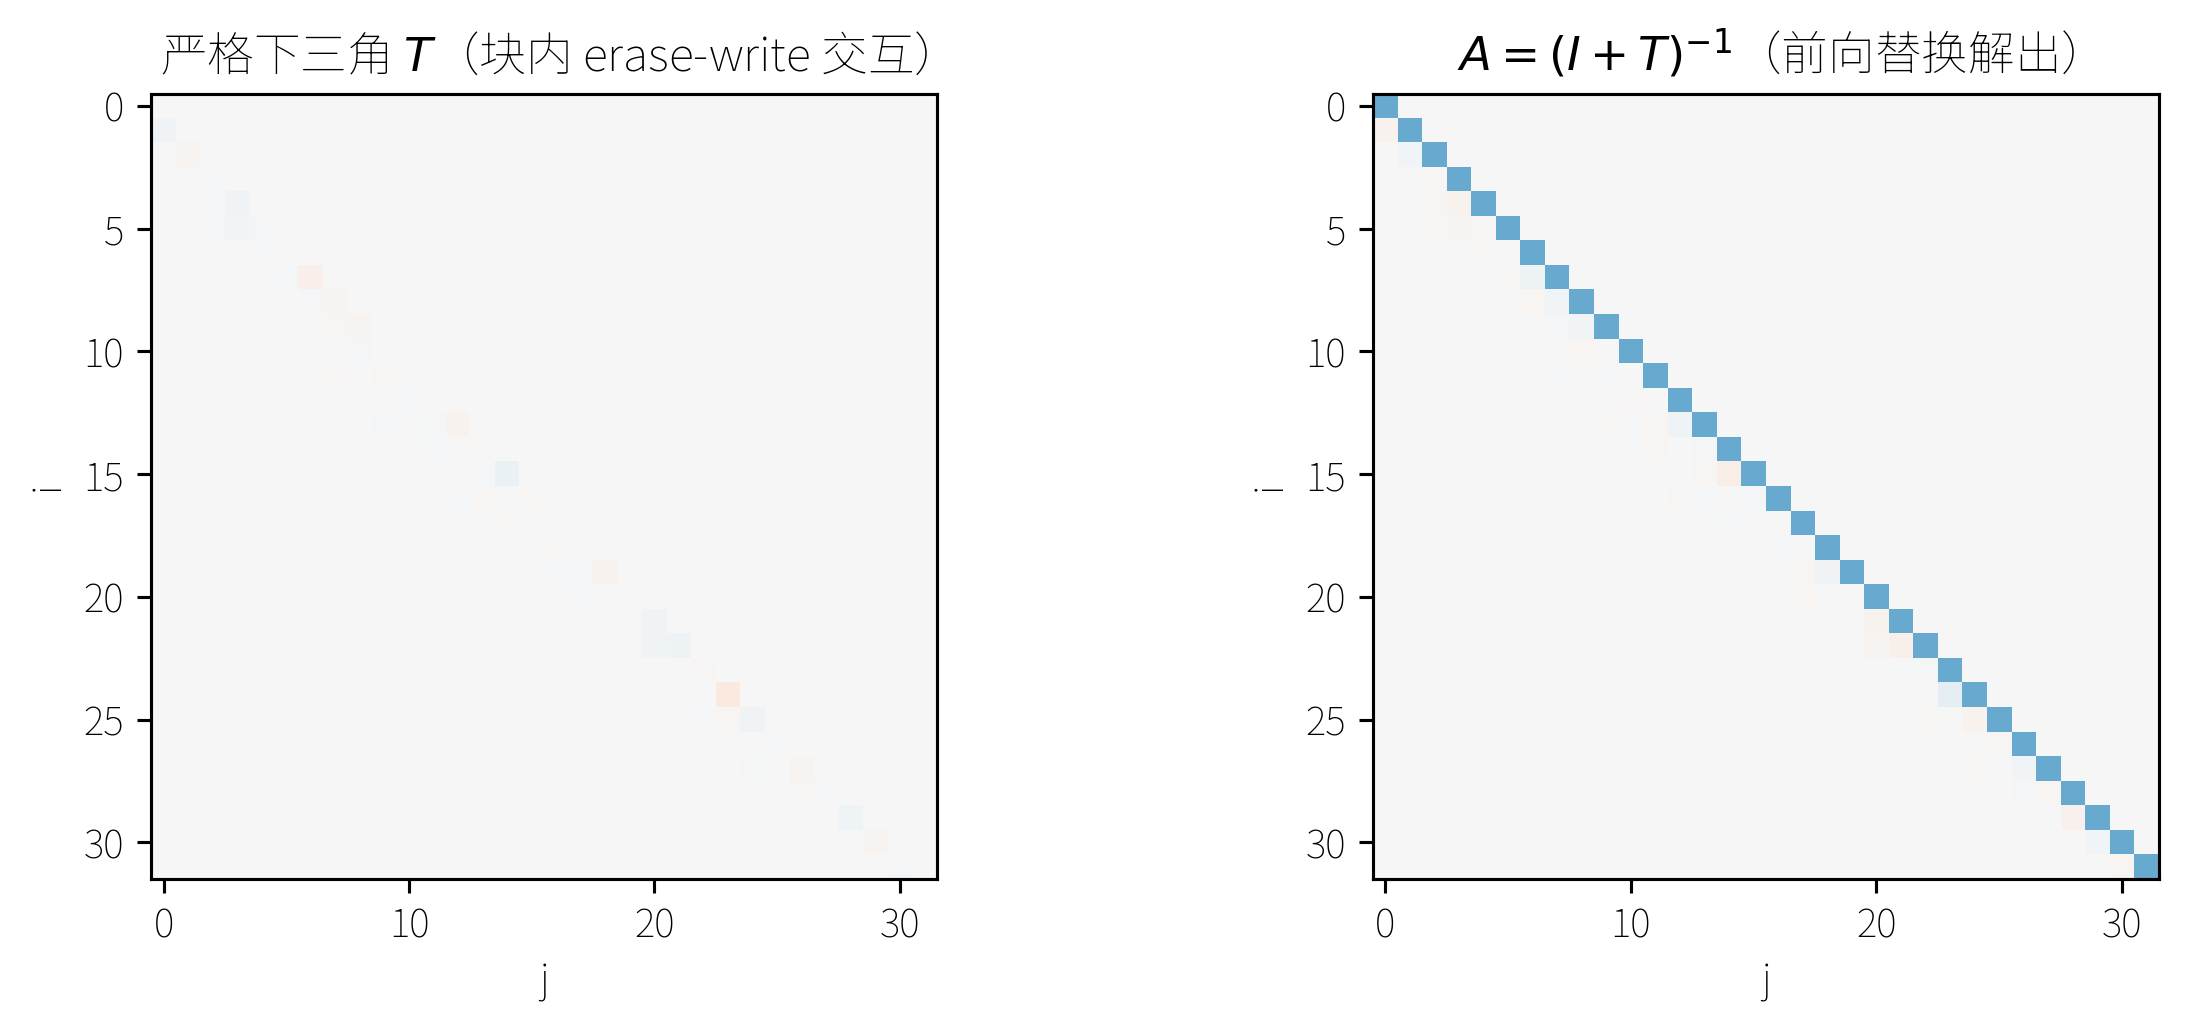

T 是严格下三角（对角线以上全 0）；A=(I+T)^(-1) 仍是单位下三角。一次求逆解开块内全部串行依赖。


In [7]:
# 把 T_lower 与 A_inv=(I+T)^{-1} 的结构画出来（取一个块）
torch.manual_seed(1)
BT, Kd = 32, 32
kk = F.normalize(torch.randn(BT, Kd), dim=-1)
bb = torch.rand(BT, Kd); gg = F.logsigmoid(torch.randn(BT, Kd)).cumsum(0)
decay = (gg[:, None, :] - gg[None, :, :]).exp()
T_lower = torch.einsum('ik,jk,ijk->ij', bb * kk, kk, decay).tril(-1)   # 严格下三角 T
A_inv = -T_lower.clone()
for i in range(1, BT):
    A_inv[i, :i] = A_inv[i, :i] + (A_inv[i, :i, None] * A_inv[:i, :i]).sum(0)
A_inv = A_inv + torch.eye(BT)

fig, ax = plt.subplots(1, 2, figsize=(9, 3.8))
ax[0].imshow(T_lower.cpu(), cmap="RdBu", vmin=-2, vmax=2); ax[0].set_title("严格下三角 $T$（块内 erase-write 交互）")
ax[1].imshow(A_inv.cpu(), cmap="RdBu", vmin=-2, vmax=2); ax[1].set_title("$A=(I+T)^{-1}$（前向替换解出）")
for a in ax: a.set_xlabel("j"); a.set_ylabel("i")
plt.tight_layout(); plt.show()
print("T 是严格下三角（对角线以上全 0）；A=(I+T)^(-1) 仍是单位下三角。一次求逆解开块内全部串行依赖。")

### 6.3 前向替换求逆 + WY 辅助量

```python
A_inv = -T_lower
for i in range(1, BT):                                       # 前向替换：单位下三角逐行求逆（§5.3）
    A_inv[..., i, :i] += (A_inv[..., i, :i, None] * A_inv[..., :i, :i]).sum(-2)
A_inv = A_inv + torch.eye(BT)
u_wy = A_inv @ (w * v)                                       # U   = (I+T)^{-1}(w⊙v)
w_wy = A_inv @ k_g_b                                         # W_wy = (I+T)^{-1}((b⊙k)⊙e^{g^cum})
k_tail = k * (g_last - g_cum).exp()                          # k ⊙ e^{g^cum_last - g^cum}，给块间状态用
```

`u_wy` 就是 §5.2 解出的块内有效写入 $U=(I+T)^{-1}(w\odot v)$；`w_wy` 是块间修正要用的 $W_{\text{wy}}$。两者都只是
对 §5 公式的直接翻译。

> **真实 Triton 对应**：前向替换在 `_fla_gdn2_chunk_intra.py` 里被**分块**成 $4\times16$ 子块——
> `b_Ai10 = -tl.dot(tl.dot(b_Ai11, b_Akk10), b_Ai00)` 这类语句逐层求解相邻/隔块/最远子块（比逐行循环更并行）；
> `u_wy/w_wy` 的重算在 `_fla_gdn2_wy_fast.py::recompute_w_u_fwd_gdn2`。

### 6.4 块间循环：状态在块之间传递

```python
S = torch.zeros(B, H, K, V)                                  # 跨块的状态
for n in range(NT):
    v_new = u_wy[:, :, n] - w_wy[:, :, n] @ S                # v^new = U - W_wy · S（§5.4）
    A_qk = einsum('bhik,bhjk,bhijk->bhij', q_n, k_n, decay_qk[:, :, n]).tril()  # 块内因果 QK^T（含衰减）
    o_intra = A_qk @ v_new                                   # 块内贡献
    o_inter = (q_n * g_cum[:, :, n].exp()) @ S               # 块间贡献：q 衰减后读起点状态
    o[:, :, n] = o_intra + o_inter
    S = S * g_last_n.exp() + k_tail[:, :, n].transpose(-1, -2) @ v_new   # 状态递推
```

这段就是 §5.4 的三个公式：用块起点状态 $S$ 修正出 $v^{\text{new}}$，输出 = 块内因果注意力 + 块间状态读出，最后把
状态向后传一个块。`NT` 个块之间**只有这一条 $S$ 的串行链**（$O(T/C)$ 步），块内全部并行——这就是 chunk-parallel
把 $O(T)$ 串行降到 $O(T/C)$ 串行的原理。

> **真实 Triton 对应**：块间状态递推在 `_fla_gdn_chunk_delta_h.py::chunk_gated_delta_rule_fwd_h`；
> 输出 $o_{\text{intra}}+o_{\text{inter}}$ 在 `_fla_gdn2_gla_chunk.py::chunk_gla_fwd_o_gk`（GDN-2 复用了 GLA 的输出 kernel）。

## 7. 真实 Triton kernel：完整解耦自 fla，bitwise 一致

上面读的是可读参考实现。生产 kernel 把同一套 WY 数学写成 Triton，按 fla 的 chunk 框架拆成多文件。本仓库
**完整拷贝并解耦**（计算逻辑一字未改），靠三招脱离 fla 独立运行：**no-op dispatch**（绕后端分派）+ **cp stub**
（绕多卡 context-parallel）+ **跨章复用**（GDN-2 借用 KDA 的 `chunk_intra/gate/wy` 与 GLA 的 `gla.chunk`）。

GDN-2 的 13 个文件里，最核心的 WY 求逆在 `_fla_gdn2_chunk_intra.py`。摘其中**分块前向替换**的一小段印证 §6.3 ——
它把 $64$ 的块切成 $4$ 个 $16$ 的子块，逐层用 $-A_{ii}\,(\text{Akk})\,A_{jj}$ 解出非对角子块：

In [8]:
# 摘 chunk_intra 里"分块前向替换"的关键几行（真实 Triton，印证 §6.3 的 4×16 子块求逆）
src = (CH / "_fla_gdn2_chunk_intra.py").read_text().splitlines()
for i, line in enumerate(src):
    if "b_Ai10 = -tl.dot(" in line:
        print("\n".join(f"{i+1+j:4}: {src[i+j]}" for j in range(8)))
        break
print("\n→ b_Ai10/b_Ai21/b_Ai32 解相邻子块、b_Ai20/b_Ai31 隔块、b_Ai30 最远——正是 §6.3 前向替换的并行分块版。")
print("   完整文件见 13-gated-deltanet/_fla_gdn2_chunk_intra.py（300+ 行），其余 12 个文件见 SOURCES.md。")

 367:     b_Ai10 = -tl.dot(
 368:         tl.dot(b_Ai11, b_Akk10, input_precision=SOLVE_TRIL_DOT_PRECISION),
 369:         b_Ai00,
 370:         input_precision=SOLVE_TRIL_DOT_PRECISION,
 371:     )
 372:     b_Ai21 = -tl.dot(
 373:         tl.dot(b_Ai22, b_Akk21, input_precision=SOLVE_TRIL_DOT_PRECISION),
 374:         b_Ai11,

→ b_Ai10/b_Ai21/b_Ai32 解相邻子块、b_Ai20/b_Ai31 隔块、b_Ai30 最远——正是 §6.3 前向替换的并行分块版。
   完整文件见 13-gated-deltanet/_fla_gdn2_chunk_intra.py（300+ 行），其余 12 个文件见 SOURCES.md。


### 完整源码（供查阅全貌）

前面 §6.3 / §7 精读的片段，都摘自这一个文件——GDN-2 的 WY 求逆核心 `_fla_gdn2_chunk_intra.py`。完整贴在
下面（可滚动），方便你把"摘出来的几行"放回整段 kernel 的上下文里看：构造 `Akk`（即 $T$）、分块前向替换求
$A=(I+T)^{-1}$、再算 `Aqk` 与块内输出。入口与 autograd wrapper 在 `_fla_gdn2_chunk.py`，其余 11 个文件（chunk_fwd/
chunk_bwd/wy_fast/gate/gla.chunk/chunk_delta_h/… ）见目录与 [`SOURCES.md`](./SOURCES.md)。

In [9]:
show_code(str(CH / "_fla_gdn2_chunk_intra.py"))

### 数值验证：解耦没改任何计算

最后把本地解耦的 kernel 与 fla 原版逐位对比（定长 + 变长 `cu_seqlens`）：

In [10]:
from _fla_gdn2_chunk import chunk_gdn2 as local
B, T, H, D = 2, 512, 4, 64
gg = torch.Generator("cuda").manual_seed(1)
q = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
k = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
v = torch.randn(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
g = F.logsigmoid(torch.rand(B, T, H, D, device="cuda", dtype=torch.float32, generator=gg))
b = torch.rand(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
w = torch.rand(B, T, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)

ol, _ = local(q, k, v, g, b, w, use_qk_l2norm_in_kernel=True)
try:
    from fla.ops.gdn2 import chunk_gdn2 as flak
    of, _ = flak(q, k, v, g, b, w, use_qk_l2norm_in_kernel=True)
    d1 = (ol.float() - of.float()).abs().max().item()
    print(f"① 定长：本地解耦 vs fla 原版   max diff: {d1:.2e}   bitwise: {torch.equal(ol, of)}")
    cu = torch.tensor([0, 200, 512, 800, 1024], device="cuda", dtype=torch.int32)
    qp, kp, vp, gp, bp, wp = (x.reshape(1, B * T, H, D) for x in (q, k, v, g, b, w))
    o2, _ = local(qp, kp, vp, gp, bp, wp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    f2, _ = flak(qp, kp, vp, gp, bp, wp, use_qk_l2norm_in_kernel=True, cu_seqlens=cu)
    d2 = (o2.float() - f2.float()).abs().max().item()
    print(f"② 变长(cu_seqlens)：本地 vs fla    max diff: {d2:.2e}   bitwise: {torch.equal(o2, f2)}")
    print("→ 本地解耦与 fla 是**同一份 kernel 代码**，逻辑零改动。定长通常 bitwise；变长的 ~1e-5 差异来自")
    print("  local/fla 各自独立的 autotune（同形状下计时噪声可能选到不同 config → 不同归约顺序），属 bf16 噪声。")
except ImportError:
    print("（未装 fla，跳过原版对照）")

① 定长：本地解耦 vs fla 原版   max diff: 0.00e+00   bitwise: True


② 变长(cu_seqlens)：本地 vs fla    max diff: 1.53e-05   bitwise: False
→ 本地解耦与 fla 是**同一份 kernel 代码**，逻辑零改动。定长通常 bitwise；变长的 ~1e-5 差异来自
  local/fla 各自独立的 autotune（同形状下计时噪声可能选到不同 config → 不同归约顺序），属 bf16 噪声。


## 8. 反向传播：两个变体的梯度

§1–§7 都在讲 forward；训练靠 backward。GDN 系列的 `chunk_bwd` 和 DeltaNet（第 11 章 §6）同构，难在那两处，
gated 版再加门控：

1. 状态 $S$ 块间**串行 carry** → backward 必须**反向扫描**（BPTT，从后往前累积状态梯度 $dS$）；
2. WY 表示里有**矩阵求逆** $T=(I+L)^{-1}$ → 它的反向是**矩阵求逆的梯度**；
3. 门控 / 双门把 $e^{g^{\mathrm{cum}}}$、$b$、$w$ 折进各处 → 反向多出 $dg$（per-channel 或标量），以及 GDN-2 的 $db,dw$。

下面**两个变体都推**：先 GDN v1（per-head 标量 $g$ + 单 $\beta$），再 GDN-2（per-channel $g$ + erase/write 双门 $b,w$），
都手推**完整 backward** 用 autograd **逐位钉死**。

### 8.1 GDN v1：三个关键反向（标量门控）

GDN v1 就是 **KDA 把门控退化成 per-head 标量**（单 $\beta$）。记 forward（块 $n$，$S$ 进入状态，$\gamma=g$ 块内前缀和、标量），
把衰减折进 $\hat k=k\odot e^{\gamma},\ \bar k=k\odot e^{-\gamma},\ \hat q=q\odot e^{\gamma}$：

$$L_n=\operatorname{strict\_tril}(\operatorname{diag}(\beta)\hat K\bar K^\top),\ T_n=(I+L_n)^{-1},\ U=T_n(\beta\odot v),\ W=T_n(\beta\odot\hat k),\ A_n=\operatorname{tril}(\hat Q\bar K^\top),$$
$$\tilde u_n=U-WS,\quad o_n=\hat Q\,S+A_n\tilde u_n,\quad S'=e^{\gamma_{\text{last}}}S+k_{\text{tail}}^\top\tilde u_n,\quad k_{\text{tail}}=k\odot e^{\gamma_{\text{last}}-\gamma}.$$

**① 块内**：$d\hat Q\mathrel{+}=do_n S^\top$、$dA_n=do_n\tilde u_n^\top$、$d\tilde u_n\mathrel{+}=A_n^\top do_n$（$A_n$ 梯度 mask 回下三角）。
**② 块间 BPTT**：$dS\mathrel{+}=e^{\gamma_{\text{last}}}dS'$、$dk_{\text{tail}}=\tilde u_n dS'^\top$、$d\tilde u_n\mathrel{+}=k_{\text{tail}}dS'$，再配 $\tilde u_n=U-WS$ 补 $dS\mathrel{-}=W^\top d\tilde u_n$，**倒扫累积**。
**③ WY 求逆梯度**：$dT_n=dU(\beta\odot v)^\top+dW(\beta\odot\hat k)^\top$，$dL_n=\operatorname{strict\_tril}(-T_n^\top dT_n T_n^\top)$。
**门控 $dg$**：所有 $e^{\pm\gamma}$ 把梯度汇成 $d\gamma$（标量门 → 沿通道求和），$dg=\operatorname{rev\_cumsum}(d\gamma)$。

In [11]:
# 手推 GDN v1 chunk backward，用 autograd 逐位钉死。GDN v1 = KDA 把门控退化为 per-head 标量 g，
# 故 dg 是每 head 每步一个标量（沿通道求和）。三块反向：① 块内 ② 块间 BPTT 扫描 ③ WY 求逆梯度。
dev = "cuda"
B_, H_, T_, D_, C_ = 1, 1, 12, 4, 4
N_ = T_ // C_
eye = torch.eye(C_, device=dev)
strict = torch.triu(torch.ones(C_, C_, device=dev), 1).bool()      # 严格上三角（A 要置 0）
incl = torch.triu(torch.ones(C_, C_, device=dev), 0).bool()        # 含对角上三角（L 要置 0）

def fwd(q, k, v, g, beta, store):
    qc, kc, vc = (x.view(B_, H_, N_, C_, -1) for x in (q, k, v)); gc = g.view(B_, H_, N_, C_); bc = beta.view(B_, H_, N_, C_)
    o = torch.zeros(B_, H_, N_, C_, D_, device=dev); S = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in range(N_):
        qn, kn, vn, gn, bn = qc[:, :, n], kc[:, :, n], vc[:, :, n], gc[:, :, n], bc[:, :, n]
        gam = gn.cumsum(-1); E = gam.exp(); Ei = (-gam).exp(); glast = gam[..., -1]        # 标量 g^cum 前缀和
        hk = kn * E[..., None]; kbar = kn * Ei[..., None]; hq = qn * E[..., None]
        P = hk @ kbar.transpose(-1, -2)
        L = (bn[..., :, None] * P).masked_fill(incl, 0.)                                   # L_ij=β_i(k_i·k_j)e^{g_i-g_j}
        Tn = torch.linalg.inv(eye + L)                                                     # WY 求逆 T=(I+L)^{-1}
        vb = bn[..., None] * vn; kb = bn[..., None] * hk
        U = Tn @ vb; W = Tn @ kb
        A = (hq @ kbar.transpose(-1, -2)).masked_fill(strict, 0.)
        uh = U - W @ S
        o[:, :, n] = hq @ S + A @ uh
        Ktail = kn * (glast[..., None] - gam).exp()[..., None]
        store.append(dict(gam=gam, E=E, Ei=Ei, glast=glast, bn=bn, hk=hk, kbar=kbar, hq=hq, P=P,
                          Tn=Tn, vb=vb, kb=kb, W=W, A=A, uh=uh, Sn=S.clone(), Ktail=Ktail, qn=qn, kn=kn, vn=vn))
        S = E[..., -1][..., None, None] * S + Ktail.transpose(-1, -2) @ uh
    return o.view(B_, H_, T_, D_)

def bwd(do, store):
    doc = do.view(B_, H_, N_, C_, D_)
    dq = torch.zeros(B_, H_, N_, C_, D_, device=dev); dk = torch.zeros_like(dq); dv = torch.zeros_like(dq)
    dg = torch.zeros(B_, H_, N_, C_, device=dev); dbeta = torch.zeros(B_, H_, N_, C_, device=dev); dS = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in reversed(range(N_)):
        s = store[n]
        gam, E, Ei, glast, bn, hk, kbar, hq, P, Tn, vb, kb, W, A, uh, Sn, Ktail, qn, kn, vn = (s[x] for x in
            ("gam", "E", "Ei", "glast", "bn", "hk", "kbar", "hq", "P", "Tn", "vb", "kb", "W", "A", "uh", "Sn", "Ktail", "qn", "kn", "vn"))
        do_n = doc[:, :, n]; dgam = torch.zeros_like(gam)
        dhk = torch.zeros_like(kn); dkbar = torch.zeros_like(kn); dhq = torch.zeros_like(qn)
        El = E[..., -1]                                                                    # ② 块间 BPTT 反向扫描
        dS_state = El[..., None, None] * dS; dEl = (Sn * dS).sum((-1, -2))
        dKtail = uh @ dS.transpose(-1, -2); duh = Ktail @ dS
        dglast = dEl * El; dk[:, :, n] = dKtail * (glast[..., None] - gam).exp()[..., None]
        tmp = dKtail * Ktail; dglast = dglast + tmp.sum((-1, -2)); dgam = dgam - tmp.sum(-1)
        dhq = dhq + do_n @ Sn.transpose(-1, -2); dS_state = dS_state + hq.transpose(-1, -2) @ do_n   # ① 块内
        dA = do_n @ uh.transpose(-1, -2); duh = duh + A.transpose(-1, -2) @ do_n
        dU = duh; dW = -duh @ Sn.transpose(-1, -2); dS_state = dS_state - W.transpose(-1, -2) @ duh   # ũ=U-WS
        dAm = dA.masked_fill(strict, 0.); dhq = dhq + dAm @ kbar; dkbar = dkbar + dAm.transpose(-1, -2) @ hq
        dTn = dU @ vb.transpose(-1, -2) + dW @ kb.transpose(-1, -2)                         # ③ U=T(βv), W=T(β·k̂)
        dvb = Tn.transpose(-1, -2) @ dU; dkb = Tn.transpose(-1, -2) @ dW
        dv[:, :, n] = dvb * bn[..., None]; dbeta[:, :, n] = (dvb * vn).sum(-1) + (dkb * hk).sum(-1)
        dhk = dhk + dkb * bn[..., None]
        dL = (-Tn.transpose(-1, -2) @ dTn @ Tn.transpose(-1, -2)).masked_fill(incl, 0.)     # ③ 矩阵求逆梯度
        dP = dL * bn[..., :, None]; dbeta[:, :, n] = dbeta[:, :, n] + (dL * P).sum(-1)
        dhk = dhk + dP @ kbar; dkbar = dkbar + dP.transpose(-1, -2) @ hk
        dk[:, :, n] = dk[:, :, n] + dhk * E[..., None] + dkbar * Ei[..., None]
        dgam = dgam + (dhk * hk).sum(-1) - (dkbar * kbar).sum(-1)                           # 标量 g：沿通道求和
        dq[:, :, n] = dhq * E[..., None]; dgam = dgam + (dhq * hq).sum(-1)
        dgam[..., -1] = dgam[..., -1] + dglast
        dg[:, :, n] = dgam.flip(-1).cumsum(-1).flip(-1)                                     # 前缀和反向 = 后缀和
        dS = dS_state
    return (x.reshape(B_, H_, T_, D_) for x in (dq, dk, dv)), dg.reshape(B_, H_, T_), dbeta.reshape(B_, H_, T_)

torch.manual_seed(0)
q = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); k = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True)
v = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); g = F.logsigmoid(torch.randn(B_, H_, T_, device=dev)).requires_grad_(True)
beta = torch.rand(B_, H_, T_, device=dev, requires_grad=True)
store = []; o = fwd(q, k, v, g, beta, store); do = torch.randn_like(o); o.backward(do)
o_rec = gated_delta_recurrent(q, k, v, g, beta, l2norm=False, scale=1.0)
print(f"可微 chunk fwd vs gated_delta_recurrent   max diff = {(o.detach() - o_rec).abs().max().item():.2e}")
(dq_m, dk_m, dv_m), dg_m, db_m = bwd(do, store)
for nm, a, b in [("dq", dq_m, q.grad), ("dk", dk_m, k.grad), ("dv", dv_m, v.grad), ("dg", dg_m, g.grad), ("dβ", db_m, beta.grad)]:
    print(f"{nm}: 手推 vs autograd  max diff = {(a - b).abs().max().item():.2e}")
print("→ GDN v1 手推 backward（① 块内 ② 块间 BPTT 扫描 ③ WY 求逆梯度 + 标量门控 dg）与 autograd 逐位一致。")

可微 chunk fwd vs gated_delta_recurrent   max diff = 1.01e-06
dq: 手推 vs autograd  max diff = 0.00e+00
dk: 手推 vs autograd  max diff = 4.77e-07
dv: 手推 vs autograd  max diff = 0.00e+00
dg: 手推 vs autograd  max diff = 1.31e-06
dβ: 手推 vs autograd  max diff = 0.00e+00
→ GDN v1 手推 backward（① 块内 ② 块间 BPTT 扫描 ③ WY 求逆梯度 + 标量门控 dg）与 autograd 逐位一致。


### 8.2 GDN-2 的增量：erase / write 双门梯度

GDN-2 把单 $\beta$ 换成 **erase 门 $b\in\mathbb R^K$**（折进 key：$\widehat{bk}=(b\odot k)\odot e^{\gamma}$）和
**write 门 $w\in\mathbb R^V$**（折进 value：$w\odot v$），门控 $g$ 是 per-channel。于是 WY 三量变成

$$L_n=\operatorname{strict\_tril}(\widehat{bk}\,\bar K^\top),\qquad U=T_n(w\odot v),\qquad W=T_n\,\widehat{bk}\qquad(\text{无 }\beta).$$

反向的**三块结构（块内 / BPTT / WY 求逆）完全不变**，只是链尾不同：$U=T_n(w\odot v)$ 反传出 $dw=dU'\odot v$（其中 $dU'=T_n^\top dU$）；
$\widehat{bk}=(b\odot k)\odot e^{\gamma}$ 反传出 $db=d(bk)\odot k$。**少了 $d\beta$，多了 $db,dw$**，$dg$ 仍是 per-channel。

In [12]:
# 手推 GDN-2 chunk backward，用 autograd 逐位钉死。相对 GDN v1/KDA：去掉单 β，换成 erase 门 b∈R^K（折进 k̂）
# 与 write 门 w∈R^V（折进 v）→ 反向多出 db、dw，少了 dβ。其余三块结构（块内/BPTT/WY 求逆）不变。
dev = "cuda"
B_, H_, T_, D_, C_ = 1, 1, 12, 4, 4
N_ = T_ // C_
eye = torch.eye(C_, device=dev)
strict = torch.triu(torch.ones(C_, C_, device=dev), 1).bool()
incl = torch.triu(torch.ones(C_, C_, device=dev), 0).bool()

def fwd(q, k, v, g, b, w, store):
    qc, kc, vc, gc, bgate, wgate = (x.view(B_, H_, N_, C_, -1) for x in (q, k, v, g, b, w))
    o = torch.zeros(B_, H_, N_, C_, D_, device=dev); S = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in range(N_):
        qn, kn, vn, gn, bn, wn = qc[:, :, n], kc[:, :, n], vc[:, :, n], gc[:, :, n], bgate[:, :, n], wgate[:, :, n]
        gam = gn.cumsum(-2); E = gam.exp(); Ei = (-gam).exp(); glast = gam[..., -1, :]      # per-channel g^cum
        bk = bn * kn; hbk = bk * E; kbar = kn * Ei; hq = qn * E                             # erase 门折进 k̂
        L = (hbk @ kbar.transpose(-1, -2)).masked_fill(incl, 0.)                            # L_ij=(b_i k_i)·k_j e^{g_i-g_j}（无 β）
        Tn = torch.linalg.inv(eye + L)
        wv = wn * vn                                                                        # write 门折进 v
        U = Tn @ wv; W = Tn @ hbk
        A = (hq @ kbar.transpose(-1, -2)).masked_fill(strict, 0.)
        uh = U - W @ S
        o[:, :, n] = hq @ S + A @ uh
        Ktail = kn * (glast[..., None, :] - gam).exp()
        store.append(dict(gam=gam, E=E, Ei=Ei, glast=glast, bn=bn, wn=wn, bk=bk, hbk=hbk, kbar=kbar, hq=hq,
                          Tn=Tn, wv=wv, W=W, A=A, uh=uh, Sn=S.clone(), Ktail=Ktail, qn=qn, kn=kn, vn=vn))
        S = E[..., -1, :][..., None] * S + Ktail.transpose(-1, -2) @ uh
    return o.view(B_, H_, T_, D_)

def bwd(do, store):
    doc = do.view(B_, H_, N_, C_, D_)
    dq = torch.zeros(B_, H_, N_, C_, D_, device=dev); dk = torch.zeros_like(dq); dv = torch.zeros_like(dq)
    dg = torch.zeros_like(dq); db = torch.zeros_like(dq); dw = torch.zeros_like(dq); dS = torch.zeros(B_, H_, D_, D_, device=dev)
    for n in reversed(range(N_)):
        s = store[n]
        gam, E, Ei, glast, bn, wn, bk, hbk, kbar, hq, Tn, wv, W, A, uh, Sn, Ktail, qn, kn, vn = (s[x] for x in
            ("gam", "E", "Ei", "glast", "bn", "wn", "bk", "hbk", "kbar", "hq", "Tn", "wv", "W", "A", "uh", "Sn", "Ktail", "qn", "kn", "vn"))
        do_n = doc[:, :, n]; dgam = torch.zeros_like(gam)
        dhbk = torch.zeros_like(kn); dkbar = torch.zeros_like(kn); dhq = torch.zeros_like(qn)
        El = E[..., -1, :]                                                                  # ② 块间 BPTT 反向扫描
        dS_state = El[..., None] * dS; dEl = (Sn * dS).sum(-1)
        dKtail = uh @ dS.transpose(-1, -2); duh = Ktail @ dS
        dglast = dEl * El; dk[:, :, n] = dKtail * (glast[..., None, :] - gam).exp()
        tmp = dKtail * Ktail; dglast = dglast + tmp.sum(-2); dgam = dgam - tmp
        dhq = dhq + do_n @ Sn.transpose(-1, -2); dS_state = dS_state + hq.transpose(-1, -2) @ do_n   # ① 块内
        dA = do_n @ uh.transpose(-1, -2); duh = duh + A.transpose(-1, -2) @ do_n
        dU = duh; dW = -duh @ Sn.transpose(-1, -2); dS_state = dS_state - W.transpose(-1, -2) @ duh   # ũ=U-WS
        dAm = dA.masked_fill(strict, 0.); dhq = dhq + dAm @ kbar; dkbar = dkbar + dAm.transpose(-1, -2) @ hq
        dTn = dU @ wv.transpose(-1, -2) + dW @ hbk.transpose(-1, -2)                        # ③ U=T(w∘v), W=T·(b∘k̂)
        dwv = Tn.transpose(-1, -2) @ dU; dhbk = dhbk + Tn.transpose(-1, -2) @ dW
        dw[:, :, n] = dwv * vn; dv[:, :, n] = dwv * wn                                      # write 门梯度 dw
        dL = (-Tn.transpose(-1, -2) @ dTn @ Tn.transpose(-1, -2)).masked_fill(incl, 0.)     # ③ 矩阵求逆梯度（无 β）
        dhbk = dhbk + dL @ kbar; dkbar = dkbar + dL.transpose(-1, -2) @ hbk
        dbk = dhbk * E; dgam = dgam + dhbk * hbk                                            # hbk=(b∘k)∘e^{g^cum}
        db[:, :, n] = dbk * kn; dk[:, :, n] = dk[:, :, n] + dbk * bn                        # erase 门梯度 db
        dk[:, :, n] = dk[:, :, n] + dkbar * Ei; dgam = dgam - dkbar * kbar
        dq[:, :, n] = dhq * E; dgam = dgam + dhq * hq
        dgam[..., -1, :] = dgam[..., -1, :] + dglast
        dg[:, :, n] = dgam.flip(-2).cumsum(-2).flip(-2)                                     # 前缀和反向 = 后缀和
        dS = dS_state
    return (x.reshape(B_, H_, T_, D_) for x in (dq, dk, dv, dg, db, dw))

torch.manual_seed(0)
q = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); k = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True)
v = torch.randn(B_, H_, T_, D_, device=dev, requires_grad=True); g = F.logsigmoid(torch.randn(B_, H_, T_, D_, device=dev)).requires_grad_(True)
b = torch.rand(B_, H_, T_, D_, device=dev, requires_grad=True); w = torch.rand(B_, H_, T_, D_, device=dev, requires_grad=True)
store = []; o = fwd(q, k, v, g, b, w, store); do = torch.randn_like(o); o.backward(do)
o_rec = gdn2_recurrent(q, k, v, g, b, w, l2norm=False, scale=1.0)
print(f"可微 chunk fwd vs gdn2_recurrent     max diff = {(o.detach() - o_rec).abs().max().item():.2e}")
dq_m, dk_m, dv_m, dg_m, db_m, dw_m = bwd(do, store)
for nm, a, bb in [("dq", dq_m, q.grad), ("dk", dk_m, k.grad), ("dv", dv_m, v.grad),
                  ("dg", dg_m, g.grad), ("db", db_m, b.grad), ("dw", dw_m, w.grad)]:
    print(f"{nm}: 手推 vs autograd  max diff = {(a - bb).abs().max().item():.2e}")
print("→ GDN-2 手推 backward（① 块内 ② 块间 BPTT 扫描 ③ WY 求逆梯度 + 双门 db/dw + per-channel dg）与 autograd 逐位一致。")

可微 chunk fwd vs gdn2_recurrent     max diff = 7.15e-07
dq: 手推 vs autograd  max diff = 0.00e+00
dk: 手推 vs autograd  max diff = 4.77e-07
dv: 手推 vs autograd  max diff = 0.00e+00
dg: 手推 vs autograd  max diff = 2.38e-07
db: 手推 vs autograd  max diff = 5.96e-08
dw: 手推 vs autograd  max diff = 0.00e+00
→ GDN-2 手推 backward（① 块内 ② 块间 BPTT 扫描 ③ WY 求逆梯度 + 双门 db/dw + per-channel dg）与 autograd 逐位一致。


### 8.3 对应到真实 kernel

GDN / GDN-2 把 backward 拆成几个 kernel（见 §7 完整源码里的 `*_bwd`）：

| 手推的反向 | GDN v1 | GDN-2 |
|---|---|---|
| ② 块间反向扫描（$dS$、$du$） | `_fla_gdn_chunk_delta_h.py :: chunk_gated_delta_rule_bwd_dhu` | `_fla_gdn2_chunk.py :: chunk_gdn2_bwd`（编排） |
| ① 块内 $dq/dk/dw/dg$ 与 $dv$ | `_fla_gdn_chunk_o.py :: chunk_bwd_dqkwg / chunk_bwd_dv` | `_fla_gdn2_chunk_intra.py :: chunk_gdn2_bwd_intra` |
| ③ WY 求逆梯度 | `_fla_gdn_wy_fast.py :: *_bwd` | `_fla_gdn2_wy_fast.py :: *wy_dqkg` |
| 门控 $dg$（GDN-2 再 + $db,dw$） | 前缀和反向 + gate bwd | 前缀和反向 + 双门 gate bwd |

**这套 backward（BPTT 扫描 + WY 求逆梯度 + 门控/双门梯度）是 11→12→13 一脉相承的**：DeltaNet 是无门控原型，KDA/GDN
加 per-channel/标量 $dg$，GDN-2 再把单 $\beta$ 的梯度拆成 $db,dw$ 两个门。

### 变长序列（cu_seqlens）—— 本章 kernel 同样支持

和第 10 章 GLA 一样，本章 kernel 原生支持**变长**：多条不等长序列 packing 成一条（`batch=1`）+ `cu_seqlens` 标记边界，
内部用 `prepare_chunk_indices` 让块不跨序列、状态在每条序列开头重置。**完整原理与图示见第 10 章 §6**；这里只验证本章
`chunk_gdn2` 同样满足"packed 一次 == 逐条单独跑"。

In [13]:
H, D = 4, 64
lens = [100, 250, 160]; total = sum(lens)                       # 3 条不等长序列
cu = torch.tensor([0, 100, 350, 510], device="cuda", dtype=torch.int32)
gg = torch.Generator("cuda").manual_seed(7)
qv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
kv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
vv = torch.randn(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
from _fla_gdn2_chunk import chunk_gdn2
gv = torch.nn.functional.logsigmoid(torch.randn(1, total, H, D, device="cuda", generator=gg))
bb = torch.rand(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
ww = torch.rand(1, total, H, D, device="cuda", dtype=torch.bfloat16, generator=gg)
o_packed = chunk_gdn2(qv, kv, vv, gv, bb, ww, cu_seqlens=cu, use_qk_l2norm_in_kernel=True)[0]                                          # (a) packed 一次：传 cu_seqlens
o_each = []                                                     # (b) 逐条单独当定长各跑一次
for i in range(len(lens)):
    s, e = cu[i].item(), cu[i + 1].item()
    o_each.append(chunk_gdn2(qv[:, s:e].contiguous(), kv[:, s:e].contiguous(), vv[:, s:e].contiguous(), gv[:, s:e].contiguous(), bb[:, s:e].contiguous(), ww[:, s:e].contiguous(), use_qk_l2norm_in_kernel=True)[0])
o_each = torch.cat(o_each, dim=1)
print(f"packed(cu_seqlens 一次) vs 逐条单独跑   max diff: {(o_packed - o_each).abs().max().item():.2e}")
print("→ packed≡逐条（bf16 逐位一致）：块不跨序列、状态在每条序列开头重置。变长完整原理见第 10 章 §6。")

packed(cu_seqlens 一次) vs 逐条单独跑   max diff: 0.00e+00
→ packed≡逐条（bf16 逐位一致）：块不跨序列、状态在每条序列开头重置。变长完整原理见第 10 章 §6。


## 9. 复杂度：$O(S)$ vs full attention $O(S^2)$

GDN/GDN-2 都是线性复杂度。GDN-2 多了 per-channel 双门控，每步常数更大（略慢于 GDN），交叉点更靠后。

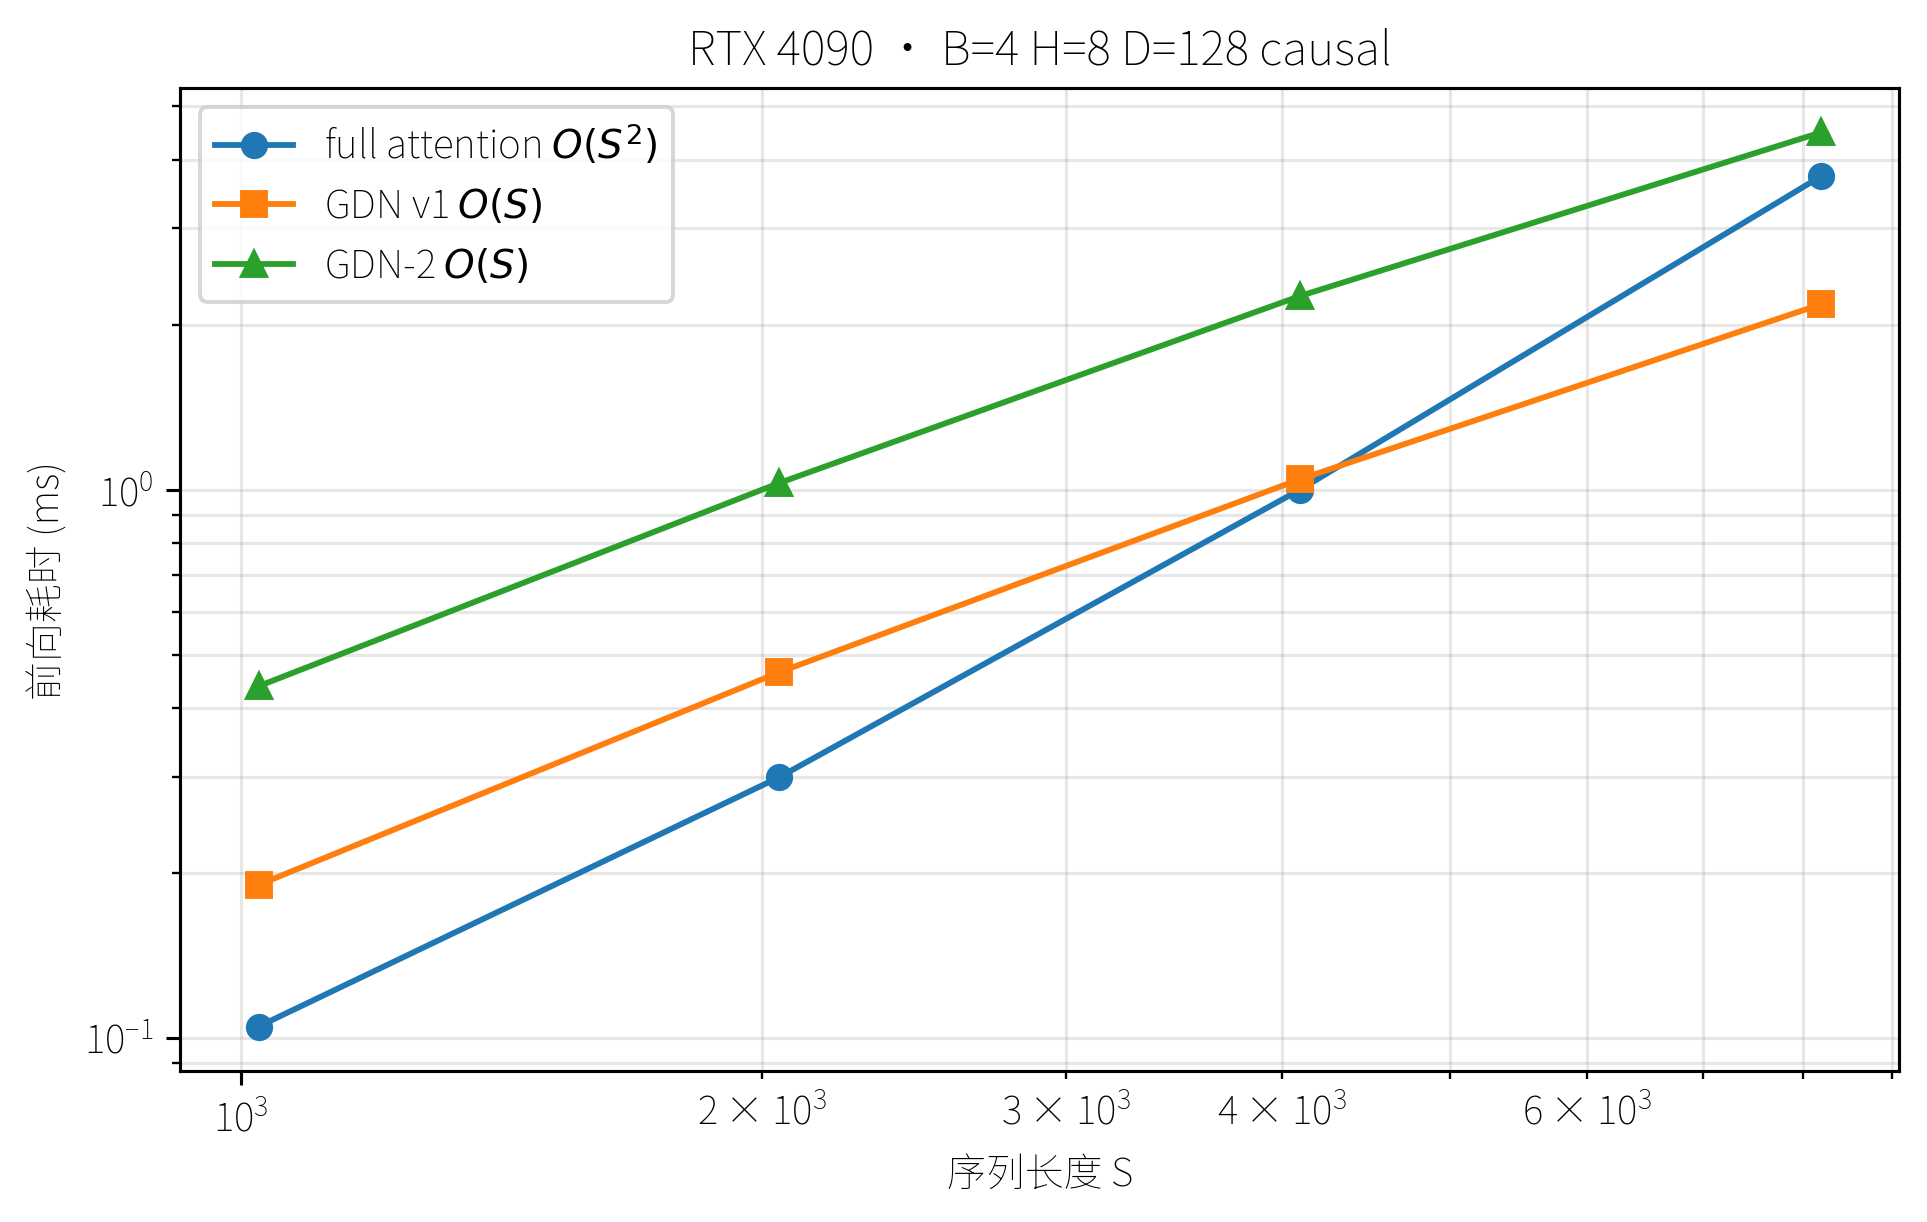

S= 1024  full  0.105ms  GDN  0.190ms (0.55×)  GDN-2  0.438ms (0.24×)
S= 2048  full  0.299ms  GDN  0.465ms (0.64×)  GDN-2  1.029ms (0.29×)
S= 4096  full  1.001ms  GDN  1.046ms (0.96×)  GDN-2  2.256ms (0.44×)
S= 8192  full  3.727ms  GDN  2.178ms (1.71×)  GDN-2  4.481ms (0.83×)


In [14]:
from common import bench_ms
from gdn_triton import gdn_chunk
from gdn2_triton import gdn2_chunk

B, H, D = 4, 8, 128
Ss = [1024, 2048, 4096, 8192]
full, gdn_t, gdn2_t = [], [], []
for S in Ss:
    q = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    k = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    v = torch.randn(B, H, S, D, device="cuda", dtype=torch.float16)
    qb, kb, vb = (x.to(torch.bfloat16) for x in (q, k, v))
    g1 = F.logsigmoid(torch.randn(B, H, S, device="cuda")); beta = torch.rand(B, H, S, device="cuda", dtype=torch.bfloat16)
    g2 = F.logsigmoid(torch.randn(B, H, S, D, device="cuda"))
    bb = torch.rand(B, H, S, D, device="cuda", dtype=torch.bfloat16); ww = torch.rand(B, H, S, D, device="cuda", dtype=torch.bfloat16)
    full.append(bench_ms(lambda: F.scaled_dot_product_attention(q, k, v, is_causal=True)))
    gdn_t.append(bench_ms(lambda: gdn_chunk(qb, kb, vb, g1, beta)))
    gdn2_t.append(bench_ms(lambda: gdn2_chunk(qb, kb, vb, g2, bb, ww)))

plt.figure(figsize=(7, 4.5))
plt.plot(Ss, full, "o-", label="full attention $O(S^2)$")
plt.plot(Ss, gdn_t, "s-", label="GDN v1 $O(S)$")
plt.plot(Ss, gdn2_t, "^-", label="GDN-2 $O(S)$")
plt.xlabel("序列长度 S"); plt.ylabel("前向耗时 (ms)"); plt.yscale("log"); plt.xscale("log")
plt.title("RTX 4090 · B=4 H=8 D=128 causal"); plt.legend(); plt.grid(alpha=0.3, which="both")
plt.tight_layout(); plt.show()
for i, S in enumerate(Ss):
    print(f"S={S:>5}  full {full[i]:6.3f}ms  GDN {gdn_t[i]:6.3f}ms ({full[i]/gdn_t[i]:.2f}×)  "
          f"GDN-2 {gdn2_t[i]:6.3f}ms ({full[i]/gdn2_t[i]:.2f}×)")

## 10. 收尾

这一章把 gated delta rule 推到了生产形态，关键脉络：

1. **delta rule 的几何**（§2）：$(I-\beta k k^\top)$ 是沿 $k$ 方向的擦除，"先擦后写"根治键冲突；
2. **门控**（§3）：加 $\operatorname{diag}(e^{g})$ 让状态主动遗忘——KDA 逐通道、GDN v1 逐头标量；
3. **erase/write 解耦**（§4）：GDN-2 把单 $\beta$ 拆成 per-channel 的 $b,w$ 两个门，表达力更强；
4. **WY 表示**（§5）：把块内串行擦除写成 $(I+T)U=WV$，一次三角求逆解开，是 chunk 并行的地基；
5. **逐段精读 + 真实 kernel**（§6–§7）：可读参考实现的每一段都对应一条公式与一处 Triton kernel，本仓库
   完整解耦自 fla，与原版 bitwise 一致；
6. **反向传播**（§8）：GDN v1 与 GDN-2 两个变体都手推了 backward（块内 + 块间 BPTT 扫描 + WY 求逆梯度 + 门控/双门 $dg,db,dw$），与 autograd 逐位钉死。

退化链 $\textbf{DeltaNet}\to\textbf{KDA}\to\textbf{GDN v1}\to\textbf{GDN-2}$ 我们逐节做了数值验证。线性注意力线
（10 GLA → 11 DeltaNet → 12 KDA → 13 GDN/GDN-2）到此完成；下一章转向 **DeepSeek V4** 的混合压缩稀疏注意力。